# Experiment multi-asset: BTC vs GLD vs USO

Aquest notebook reformula el problema com una tasca d'assignació dinàmica d'actius.

L'agent decideix quin actiu mantenir en cada pas temporal:

- `0 = BTC`
- `1 = GLD`
- `2 = USO`

In [17]:
import sys
from pathlib import Path

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from env.trading_env_multi_asset_dynamic_cost import TradingEnv
from stable_baselines3 import PPO

## 1. Configuració de l'experiment

In [18]:
EXPERIMENT_NAME = "multi_asset_relative_strength_dynamic_cost"
ACTION_TYPE = "asset_allocation_with_dynamic_switching_cost"

BASE_TRANSACTION_COST = 0.001
DYNAMIC_COST_WEIGHT = 0.05
INACTIVITY_PENALTY = 0.001

TOTAL_TIMESTEPS = 50000
TRAIN_SPLIT = 0.8

print("Experiment:", EXPERIMENT_NAME)
print("Action type:", ACTION_TYPE)
print("Base transaction cost:", BASE_TRANSACTION_COST)
print("Dynamic cost weight:", DYNAMIC_COST_WEIGHT)
print("Inactivity penalty:", INACTIVITY_PENALTY)
print("Timesteps:", TOTAL_TIMESTEPS)
print("Train split:", TRAIN_SPLIT)

Experiment: multi_asset_relative_strength_dynamic_cost
Action type: asset_allocation_with_dynamic_switching_cost
Base transaction cost: 0.001
Dynamic cost weight: 0.05
Inactivity penalty: 0.001
Timesteps: 50000
Train split: 0.8


## 2. Descàrrega de dades

In [19]:
btc = yf.download("BTC-USD", period="730d", interval="1h", auto_adjust=False)
gld = yf.download("GLD", period="730d", interval="1h", auto_adjust=False)
uso = yf.download("USO", period="730d", interval="1h", auto_adjust=False)

print("BTC shape:", btc.shape)
print("GLD shape:", gld.shape)
print("USO shape:", uso.shape)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

BTC shape: (17353, 6)
GLD shape: (5077, 6)
USO shape: (5078, 6)


## 3. Neteja de columnes

In [20]:
btc.columns = btc.columns.get_level_values(0)
gld.columns = gld.columns.get_level_values(0)
uso.columns = uso.columns.get_level_values(0)

btc.columns.name = None
gld.columns.name = None
uso.columns.name = None

print(btc.columns)
print(gld.columns)
print(uso.columns)

btc.head(), gld.head(), uso.head()

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')
Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')
Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


(                              Adj Close         Close          High  \
 Datetime                                                              
 2024-05-03 00:00:00+00:00  59048.851562  59048.851562  59128.941406   
 2024-05-03 01:00:00+00:00  59359.304688  59359.304688  59490.843750   
 2024-05-03 02:00:00+00:00  59561.472656  59561.472656  59928.902344   
 2024-05-03 03:00:00+00:00  59740.558594  59740.558594  59992.253906   
 2024-05-03 04:00:00+00:00  59585.773438  59585.773438  59825.601562   
 
                                     Low          Open     Volume  
 Datetime                                                          
 2024-05-03 00:00:00+00:00  58851.484375  59087.492188          0  
 2024-05-03 01:00:00+00:00  59040.808594  59053.320312          0  
 2024-05-03 02:00:00+00:00  59302.406250  59336.199219   26249216  
 2024-05-03 03:00:00+00:00  59557.214844  59557.214844  431472640  
 2024-05-03 04:00:00+00:00  59573.722656  59736.585938          0  ,
                 

## 4. Normalització temporal i sincronització

In [21]:
btc_1h = btc[["Close"]].copy()
gld_1h = gld[["Close"]].copy()
uso_1h = uso[["Close"]].copy()

btc_1h.index = btc_1h.index.floor("1h")
gld_1h.index = gld_1h.index.floor("1h")
uso_1h.index = uso_1h.index.floor("1h")

btc_1h = btc_1h.rename(columns={"Close": "btc_close"})
gld_1h = gld_1h.rename(columns={"Close": "gld_close"})
uso_1h = uso_1h.rename(columns={"Close": "uso_close"})

print(btc_1h.head())
print(gld_1h.head())
print(uso_1h.head())

                              btc_close
Datetime                               
2024-05-03 00:00:00+00:00  59048.851562
2024-05-03 01:00:00+00:00  59359.304688
2024-05-03 02:00:00+00:00  59561.472656
2024-05-03 03:00:00+00:00  59740.558594
2024-05-03 04:00:00+00:00  59585.773438
                            gld_close
Datetime                             
2023-06-05 13:00:00+00:00  181.940002
2023-06-05 14:00:00+00:00  181.850006
2023-06-05 15:00:00+00:00  181.919998
2023-06-05 16:00:00+00:00  181.869995
2023-06-05 17:00:00+00:00  182.169998
                           uso_close
Datetime                            
2023-06-05 13:00:00+00:00  64.680000
2023-06-05 14:00:00+00:00  64.930000
2023-06-05 15:00:00+00:00  64.879997
2023-06-05 16:00:00+00:00  64.629997
2023-06-05 17:00:00+00:00  64.300003


In [22]:
common_index = btc_1h.index.intersection(gld_1h.index).intersection(uso_1h.index)

btc_sync = btc_1h.loc[common_index].copy()
gld_sync = gld_1h.loc[common_index].copy()
uso_sync = uso_1h.loc[common_index].copy()

print("BTC sync shape:", btc_sync.shape)
print("GLD sync shape:", gld_sync.shape)
print("USO sync shape:", uso_sync.shape)
print("Start:", common_index.min())
print("End:", common_index.max())

BTC sync shape: (3447, 1)
GLD sync shape: (3447, 1)
USO sync shape: (3447, 1)
Start: 2024-05-03 13:00:00+00:00
End: 2026-05-01 19:00:00+00:00


In [23]:
df = btc_sync.join(gld_sync, how="inner").join(uso_sync, how="inner")

print("Merged shape:", df.shape)
df.head()

Merged shape: (3447, 3)


,btc_close,gld_close,uso_close
Datetime,,,
2024-05-03 13:00:00+00:00,61662.195312,211.570007,75.550003
2024-05-03 14:00:00+00:00,61660.226562,212.110001,75.570000
2024-05-03 15:00:00+00:00,61766.851562,212.589996,75.440002
2024-05-03 16:00:00+00:00,61674.062500,212.835007,75.410004
2024-05-03 17:00:00+00:00,61852.609375,212.679993,75.070000


## 5. Creació de retorns i agregació a 4 hores

In [24]:
df["btc_ret_1h"] = df["btc_close"].pct_change()
df["gld_ret_1h"] = df["gld_close"].pct_change()
df["uso_ret_1h"] = df["uso_close"].pct_change()

df = df.dropna().copy()

df.head()

,btc_close,gld_close,uso_close,btc_ret_1h,gld_ret_1h,uso_ret_1h
Datetime,,,,,,
2024-05-03 14:00:00+00:00,61660.226562,212.110001,75.570000,-0.000032,0.002552,0.000265
2024-05-03 15:00:00+00:00,61766.851562,212.589996,75.440002,0.001729,0.002263,-0.001720
2024-05-03 16:00:00+00:00,61674.062500,212.835007,75.410004,-0.001502,0.001153,-0.000398
2024-05-03 17:00:00+00:00,61852.609375,212.679993,75.070000,0.002895,-0.000728,-0.004509
2024-05-03 18:00:00+00:00,61821.207031,212.720001,75.099998,-0.000508,0.000188,0.000400


In [25]:
df_4h = df.resample("4h").agg({
    "btc_close": "last",
    "gld_close": "last",
    "uso_close": "last",
    "btc_ret_1h": "sum",
    "gld_ret_1h": "sum",
    "uso_ret_1h": "sum",
}).dropna().copy()

print("4H shape:", df_4h.shape)
df_4h.head()

4H shape: (1151, 6)


,btc_close,gld_close,uso_close,btc_ret_1h,gld_ret_1h,uso_ret_1h
Datetime,,,,,,
2024-05-03 12:00:00+00:00,61766.851562,212.589996,75.440002,0.001697,0.004815,-0.001456
2024-05-03 16:00:00+00:00,62025.589844,212.979996,75.150002,0.004191,0.001835,-0.003841
2024-05-06 12:00:00+00:00,63701.535156,215.139999,75.970001,0.027139,0.010143,0.010888
2024-05-06 16:00:00+00:00,63191.597656,215.169998,75.650002,-0.007982,0.000141,-0.004177
2024-05-07 12:00:00+00:00,63724.531250,214.300003,75.800003,0.008454,-0.004047,0.002050


## 6. Feature engineering

In [26]:
# Target returns: retorns utilitzats per calcular la recompensa
df_4h["btc_target_ret"] = df_4h["btc_close"].pct_change()
df_4h["gld_target_ret"] = df_4h["gld_close"].pct_change()
df_4h["uso_target_ret"] = df_4h["uso_close"].pct_change()

# Features bàsiques amb informació passada
df_4h["btc_ret_4h"] = df_4h["btc_target_ret"].shift(1)
df_4h["gld_ret_4h"] = df_4h["gld_target_ret"].shift(1)
df_4h["uso_ret_4h"] = df_4h["uso_target_ret"].shift(1)

df_4h["btc_vol_12"] = df_4h["btc_target_ret"].rolling(12).std().shift(1)
df_4h["gld_vol_12"] = df_4h["gld_target_ret"].rolling(12).std().shift(1)
df_4h["uso_vol_12"] = df_4h["uso_target_ret"].rolling(12).std().shift(1)

# Momentum passat: rendiment acumulat en finestres més llargues
df_4h["btc_mom_12"] = df_4h["btc_close"].pct_change(12).shift(1)
df_4h["gld_mom_12"] = df_4h["gld_close"].pct_change(12).shift(1)
df_4h["uso_mom_12"] = df_4h["uso_close"].pct_change(12).shift(1)

df_4h["btc_mom_24"] = df_4h["btc_close"].pct_change(24).shift(1)
df_4h["gld_mom_24"] = df_4h["gld_close"].pct_change(24).shift(1)
df_4h["uso_mom_24"] = df_4h["uso_close"].pct_change(24).shift(1)

# Relative strength: comparació de força relativa entre actius
df_4h["btc_vs_gld_mom_12"] = df_4h["btc_mom_12"] - df_4h["gld_mom_12"]
df_4h["btc_vs_uso_mom_12"] = df_4h["btc_mom_12"] - df_4h["uso_mom_12"]
df_4h["gld_vs_uso_mom_12"] = df_4h["gld_mom_12"] - df_4h["uso_mom_12"]

df_4h["btc_vs_gld_mom_24"] = df_4h["btc_mom_24"] - df_4h["gld_mom_24"]
df_4h["btc_vs_uso_mom_24"] = df_4h["btc_mom_24"] - df_4h["uso_mom_24"]
df_4h["gld_vs_uso_mom_24"] = df_4h["gld_mom_24"] - df_4h["uso_mom_24"]

df_4h = df_4h.dropna().copy()

print("Final 4H shape:", df_4h.shape)
df_4h.head()

Final 4H shape: (1126, 27)


,btc_close,gld_close,uso_close,btc_ret_1h,gld_ret_1h,uso_ret_1h,btc_target_ret,gld_target_ret,uso_target_ret,btc_ret_4h,...,uso_mom_12,btc_mom_24,gld_mom_24,uso_mom_24,btc_vs_gld_mom_12,btc_vs_uso_mom_12,gld_vs_uso_mom_12,btc_vs_gld_mom_24,btc_vs_uso_mom_24,gld_vs_uso_mom_24
Datetime,,,,,,,,,,,,,,,,,,,,,
2024-05-21 16:00:00+00:00,69363.851562,224.220001,76.150002,-0.004709,0.001611,0.005212,-0.004718,0.001608,0.005214,-0.002706,...,-0.002436,0.128318,0.053013,0.004175,0.070844,0.108950,0.038106,0.075304,0.124142,0.048838
2024-05-22 12:00:00+00:00,70434.546875,221.300003,75.595001,0.015375,-0.012989,-0.007253,0.015436,-0.013023,-0.007288,-0.004718,...,-0.000131,0.118310,0.052775,0.013307,0.062953,0.099796,0.036843,0.065535,0.105004,0.039468
2024-05-22 16:00:00+00:00,69718.234375,220.119995,74.889999,-0.010192,-0.005336,-0.009350,-0.010170,-0.005332,-0.009326,0.015436,...,0.008068,0.105696,0.028633,-0.004936,0.122001,0.132060,0.010059,0.077064,0.110632,0.033569
2024-05-23 12:00:00+00:00,68048.742188,216.869995,74.820000,-0.023934,-0.014792,-0.000832,-0.023946,-0.014765,-0.000935,-0.010170,...,-0.004122,0.103283,0.023005,-0.010046,0.123211,0.136595,0.013384,0.080278,0.113330,0.033051
2024-05-23 16:00:00+00:00,67128.031250,215.710007,74.459999,-0.013599,-0.005357,-0.004796,-0.013530,-0.005349,-0.004812,-0.023946,...,-0.005980,0.067858,0.011992,-0.012929,0.069975,0.058467,-0.011508,0.055865,0.080787,0.024921


## 7. Dataset de l'entorn multi-asset

In [27]:
feature_columns = [
    "btc_ret_4h",
    "btc_vol_12",
    "gld_ret_4h",
    "gld_vol_12",
    "uso_ret_4h",
    "uso_vol_12",

    "btc_mom_12",
    "gld_mom_12",
    "uso_mom_12",

    "btc_mom_24",
    "gld_mom_24",
    "uso_mom_24",

    "btc_vs_gld_mom_12",
    "btc_vs_uso_mom_12",
    "gld_vs_uso_mom_12",

    "btc_vs_gld_mom_24",
    "btc_vs_uso_mom_24",
    "gld_vs_uso_mom_24",
]

target_columns = [
    "btc_target_ret",
    "gld_target_ret",
    "uso_target_ret",
]

env_df = df_4h[feature_columns + target_columns].copy()

print(env_df.shape)
env_df.head()

(1126, 21)


,btc_ret_4h,btc_vol_12,gld_ret_4h,gld_vol_12,uso_ret_4h,uso_vol_12,btc_mom_12,gld_mom_12,uso_mom_12,btc_mom_24,...,uso_mom_24,btc_vs_gld_mom_12,btc_vs_uso_mom_12,gld_vs_uso_mom_12,btc_vs_gld_mom_24,btc_vs_uso_mom_24,gld_vs_uso_mom_24,btc_target_ret,gld_target_ret,uso_target_ret
Datetime,,,,,,,,,,,,,,,,,,,,,
2024-05-21 16:00:00+00:00,-0.002706,0.021136,-0.003072,0.005197,-0.012836,0.007127,0.106514,0.035670,-0.002436,0.128318,...,0.004175,0.070844,0.108950,0.038106,0.075304,0.124142,0.048838,-0.004718,0.001608,0.005214
2024-05-22 12:00:00+00:00,-0.004718,0.021402,0.001608,0.005164,0.005214,0.007248,0.099664,0.036712,-0.000131,0.118310,...,0.013307,0.062953,0.099796,0.036843,0.065535,0.105004,0.039468,0.015436,-0.013023,-0.007288
2024-05-22 16:00:00+00:00,0.015436,0.019438,-0.013023,0.006874,-0.007288,0.005950,0.140127,0.018127,0.008068,0.105696,...,-0.004936,0.122001,0.132060,0.010059,0.077064,0.110632,0.033569,-0.010170,-0.005332,-0.009326
2024-05-23 12:00:00+00:00,-0.010170,0.019984,-0.005332,0.007115,-0.009326,0.006557,0.132473,0.009262,-0.004122,0.103283,...,-0.010046,0.123211,0.136595,0.013384,0.080278,0.113330,0.033051,-0.023946,-0.014765,-0.000935
2024-05-23 16:00:00+00:00,-0.023946,0.017984,-0.014765,0.007459,-0.000935,0.006547,0.052487,-0.017487,-0.005980,0.067858,...,-0.012929,0.069975,0.058467,-0.011508,0.055865,0.080787,0.024921,-0.013530,-0.005349,-0.004812


## 8. Split train/test temporal

In [28]:
split_idx = int(len(env_df) * TRAIN_SPLIT)

train_data = env_df.iloc[:split_idx].copy()
test_data = env_df.iloc[split_idx:].copy()

print("train_data:", train_data.shape)
print("test_data:", test_data.shape)

train_data: (900, 21)
test_data: (226, 21)


## 9. Creació dels entorns

In [29]:
env_train_multi = TradingEnv(
    data=train_data,
    feature_columns=feature_columns,
    base_transaction_cost=BASE_TRANSACTION_COST,
    dynamic_cost_weight=DYNAMIC_COST_WEIGHT,
    inactivity_penalty=INACTIVITY_PENALTY,
)

env_test_multi = TradingEnv(
    data=test_data,
    feature_columns=feature_columns,
    base_transaction_cost=BASE_TRANSACTION_COST,
    dynamic_cost_weight=DYNAMIC_COST_WEIGHT,
    inactivity_penalty=INACTIVITY_PENALTY,
)

obs, info = env_train_multi.reset()
print("Initial observation:", obs)
print("Observation shape:", obs.shape)
print("Info:", info)

Initial observation: [-0.00270647  0.02113599 -0.00307235  0.00519702 -0.01283556  0.00712712
  0.10651411  0.0356702  -0.0024362   0.12831771  0.05301337  0.00417543
  0.07084391  0.10895031  0.0381064   0.07530435  0.12414228  0.04883793
  0.          0.        ]
Observation shape: (20,)
Info: {}


## 10. Entrenament PPO

In [30]:
model_multi = PPO(
    "MlpPolicy",
    env_train_multi,
    verbose=1,
    learning_rate=3e-4,
    n_steps=256,
    batch_size=64,
    gamma=0.99,
)

model_multi.learn(total_timesteps=TOTAL_TIMESTEPS)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------
| time/              |     |
|    fps             | 987 |
|    iterations      | 1   |
|    time_elapsed    | 0   |
|    total_timesteps | 256 |
----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 800          |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 512          |
| train/                  |              |
|    approx_kl            | 0.0046900995 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.1         |
|    explained_variance   | -4.76        |
|    learning_rate        | 0.0003       |
|    loss                 | -0.0169      |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.0058      |
|    value_loss

## 11. Funcions d'avaluació

In [31]:
def evaluate_model_multi_asset(model, env, data_df):
    obs, info = env.reset()

    done = False
    truncated = False

    equity = [1.0]
    rewards = []
    actions = []
    assets = []
    switching_costs = []
    inactivity_costs = []
    selected_returns = []
    selected_volatilities = []
    holding_durations = []

    while not (done or truncated):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = env.step(int(action))

        rewards.append(reward)
        actions.append(int(action))
        assets.append(info["asset"])
        switching_costs.append(info["switching_cost"])
        inactivity_costs.append(info["inactivity_cost"])
        selected_returns.append(info["selected_return"])
        selected_volatilities.append(info["selected_volatility"])
        holding_durations.append(info["holding_duration"])

        equity.append(equity[-1] * (1.0 + reward))

    results = pd.DataFrame({
        "reward": rewards,
        "action": actions,
        "asset": assets,
        "holding_duration": holding_durations,
        "selected_return": selected_returns,
        "selected_volatility": selected_volatilities,
        "switching_cost": switching_costs,
        "inactivity_cost": inactivity_costs,
    }, index=data_df.index[1:1+len(rewards)])

    results["equity"] = equity[1:]
    return results

def compute_metrics_multi_asset(results_df, periods_per_year=252*2):
    rets = results_df["reward"].dropna()

    cumulative_return = (1 + rets).prod() - 1

    mean_ret = rets.mean()
    vol = rets.std()

    sharpe = np.nan
    if vol > 1e-8:
        sharpe = (mean_ret / vol) * np.sqrt(periods_per_year)

    downside = rets[rets < 0].std()
    sortino = np.nan
    if downside > 1e-8:
        sortino = (mean_ret / downside) * np.sqrt(periods_per_year)

    equity = results_df["equity"]
    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    max_drawdown = drawdown.min()

    asset_changes = results_df["asset"].diff().fillna(0)
    n_switches = int((asset_changes != 0).sum())

    return {
        "cumulative_return": cumulative_return,
        "sharpe": sharpe,
        "sortino": sortino,
        "max_drawdown": max_drawdown,
        "n_switches": n_switches,
    }

## 12. Avaluació del model

In [32]:
results_multi = evaluate_model_multi_asset(model_multi, env_test_multi, test_data)

results_multi.head()

,reward,action,asset,holding_duration,selected_return,selected_volatility,switching_cost,inactivity_cost,equity
Datetime,,,,,,,,,
2025-12-23 20:00:00+00:00,0.002098,0,0,1,0.003098,0.022298,0.000000,0.001,1.002098
2025-12-24 12:00:00+00:00,0.000009,1,1,0,0.001380,0.007418,0.001371,0.000,1.002107
2025-12-24 16:00:00+00:00,-0.010494,0,0,0,-0.008407,0.021747,0.002087,0.000,0.991591
2025-12-26 12:00:00+00:00,0.001917,0,0,1,0.002917,0.019874,0.000000,0.001,0.993492
2025-12-26 16:00:00+00:00,0.014092,1,1,0,0.015451,0.007175,0.001359,0.000,1.007492


In [33]:
metrics_multi = compute_metrics_multi_asset(results_multi)

comparison_multi = pd.DataFrame(
    [metrics_multi],
    index=["MultiAsset_BTC_GLD_USO"]
)

comparison_multi

,cumulative_return,sharpe,sortino,max_drawdown,n_switches
MultiAsset_BTC_GLD_USO,-0.301349,-1.822584,-2.540566,-0.409659,152


## 13. Benchmarks buy-and-hold

In [34]:
btc_bh = (1 + test_data["btc_ret_4h"]).prod() - 1
gld_bh = (1 + test_data["gld_ret_4h"]).prod() - 1
uso_bh = (1 + test_data["uso_ret_4h"]).prod() - 1

benchmarks = pd.DataFrame(
    [{
        "BTC Buy & Hold": btc_bh,
        "GLD Buy & Hold": gld_bh,
        "USO Buy & Hold": uso_bh,
    }]
)

benchmarks

,BTC Buy & Hold,GLD Buy & Hold,USO Buy & Hold
0,-0.112645,0.042992,1.055277


## 14. Distribució d'accions i actius

In [35]:
print("Actions:")
print(results_multi["action"].value_counts())

print("\nAssets:")
print(results_multi["asset"].value_counts())

Actions:
action
0    149
1     76
Name: count, dtype: int64

Assets:
asset
0    149
1     76
Name: count, dtype: int64


## 15. Corba d'equity

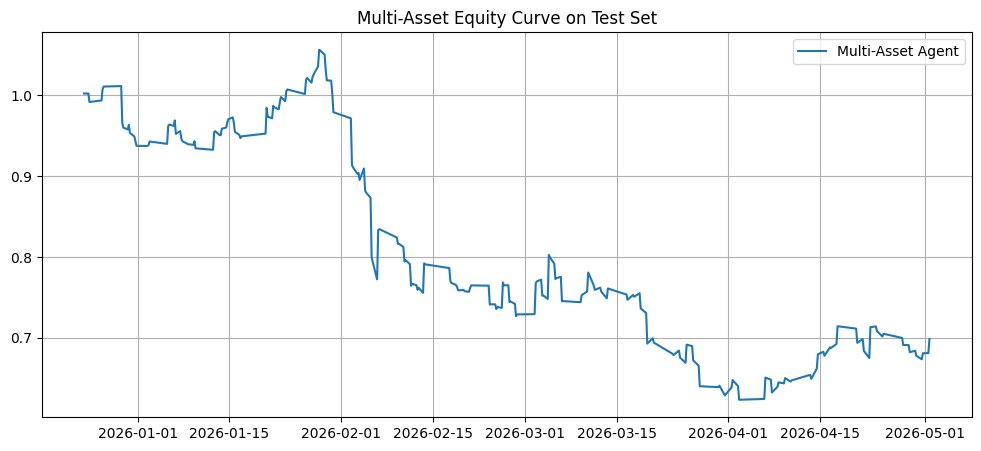

In [36]:
plt.figure(figsize=(12, 5))
plt.plot(results_multi.index, results_multi["equity"], label="Multi-Asset Agent")
plt.title("Multi-Asset Equity Curve on Test Set")
plt.legend()
plt.grid(True)
plt.show()

## 16. Comparació visual amb buy-and-hold dels actius

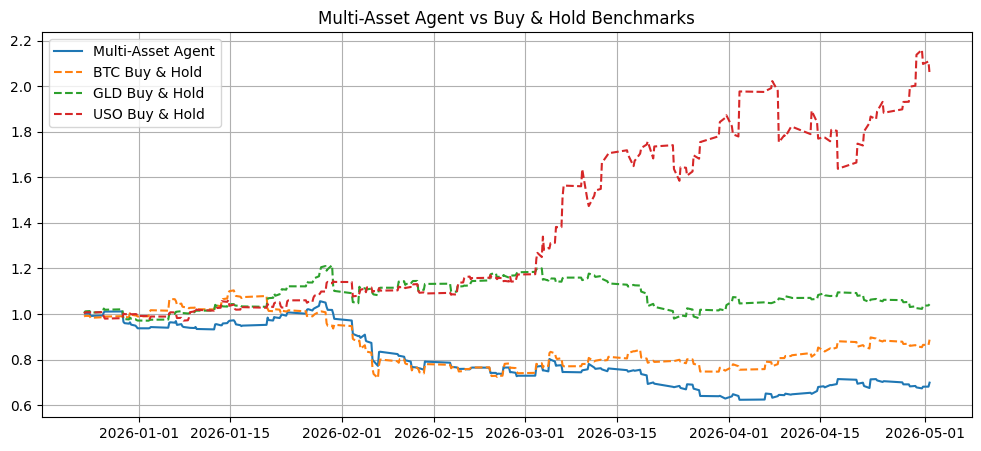

In [37]:
bh_curves = pd.DataFrame(index=test_data.index)
bh_curves["BTC_BH"] = (1 + test_data["btc_ret_4h"]).cumprod()
bh_curves["GLD_BH"] = (1 + test_data["gld_ret_4h"]).cumprod()
bh_curves["USO_BH"] = (1 + test_data["uso_ret_4h"]).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(results_multi.index, results_multi["equity"], label="Multi-Asset Agent")
plt.plot(bh_curves.index, bh_curves["BTC_BH"], label="BTC Buy & Hold", linestyle="--")
plt.plot(bh_curves.index, bh_curves["GLD_BH"], label="GLD Buy & Hold", linestyle="--")
plt.plot(bh_curves.index, bh_curves["USO_BH"], label="USO Buy & Hold", linestyle="--")
plt.title("Multi-Asset Agent vs Buy & Hold Benchmarks")
plt.legend()
plt.grid(True)
plt.show()

## 17. Guardat de resultats

In [38]:
results_dir = project_root / "results"
results_dir.mkdir(exist_ok=True)

results_multi.to_csv(results_dir / "results_multi_asset_btc_gld_uso.csv")
comparison_multi.to_csv(results_dir / "comparison_multi_asset_btc_gld_uso.csv")
benchmarks.to_csv(results_dir / "benchmarks_multi_asset_btc_gld_uso.csv")

print("Results saved in:", results_dir)

Results saved in: c:\Users\rfran\OneDrive\Documentos\UOC\Master\TFM\tfm-drl-trading\results


In [39]:
np.random.seed(42)
test_data_shuffled = test_data.sample(frac=1)

env_test_random = TradingEnv(
    data=test_data_shuffled,
    feature_columns=feature_columns,
    base_transaction_cost=BASE_TRANSACTION_COST,
    dynamic_cost_weight=DYNAMIC_COST_WEIGHT,
    inactivity_penalty=INACTIVITY_PENALTY,
)

results_random = evaluate_model_multi_asset(
    model_multi,
    env_test_random,
    test_data_shuffled
)

compute_metrics_multi_asset(results_random)

{'cumulative_return': np.float64(-0.34521082551314397),
 'sharpe': np.float64(-2.3659685797394996),
 'sortino': np.float64(-3.3636484299574976),
 'max_drawdown': np.float64(-0.3551273938528159),
 'n_switches': 154}